In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## `Data Reading`

In [290]:
gdf = gpd.read_file("clasificacion.shp")
df = pd.read_csv("parcelasStats.csv", sep=",")

## `Preprocessing`

In [ ]:
#delete columns
gdf = gdf.drop(['TRSAMPLE'], axis=1)
df = df.drop(['system:index', 'EVSAMPLE', 'TRSAMPLE'], axis=1)

#union tables (shp and csv)
data = gdf.merge(df, how='left', on='id')

#Removing null records and filtering out rows without a class
data = data.dropna()
data = data[data["EVSAMPLE"]<99]

#area calculation
data["area"] = data.iloc[:,:].geometry.area

#classes
clases = {0:"Arrozal", 1:"Citricos", 2:"Suelo desnudo"}

#selection of plots with the largest area
data = data.loc[data.groupby('EVSAMPLE')['area'].idxmax()]

#List of characteristics by type of statistical data (precipitation and temperature)
colNameTemperatura =['EVSAMPLE']
colNamePrecipitacion =['EVSAMPLE']
for name in data.columns:
    if name.endswith("temp"):
        colNameTemperatura.append(name)
    if name.endswith("pre"):
        colNamePrecipitacion.append(name)

#Two-Week periods of the year
quincenas = [i for i, _ in enumerate(colNamePrecipitacion)]
quincenas.pop(0)


0

# `Graphs`

In [ ]:
def graficos(clase, quincenas, precipitacion, temperatura):

    fig, ax1 = plt.subplots(figsize=(20,6))
    
    #precipitation graph
    color = "tab:blue"
    ax1.set_xlabel("Quincenas (año 2023)")
    ax1.set_ylabel("Precipitación (mm)", color=color)
    precipitacion_graph = ax1.plot(quincenas, precipitacion, color=color, lw=2, alpha=0.5, label="precipitación media")
    ax1.tick_params(axis='y', labelcolor=color)

    #temperature graph
    ax2 = ax1.twinx()

    color = "tab:red"
    ax2.set_ylabel("Temperatura (ºC)", color=color)
    temperatura_graph = ax2.plot(quincenas, temperatura, color=color, lw=2, alpha=0.5, label="temperatura media")
    ax2.tick_params(axis='y', labelcolor=color)

    #legend
    graphs = precipitacion_graph + temperatura_graph
    labels = [graph.get_label() for graph in graphs]
    ax1.legend(graphs, labels, loc='best')

    plt.xticks(quincenas)
    ax1.set_xticklabels(quincenas, rotation=90)
    plt.title(f'Precipitación y Temperatura media\n--Parcela tipo: {clase}--')
    
    #grid
    ax1.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.tight_layout()
    plt.show()

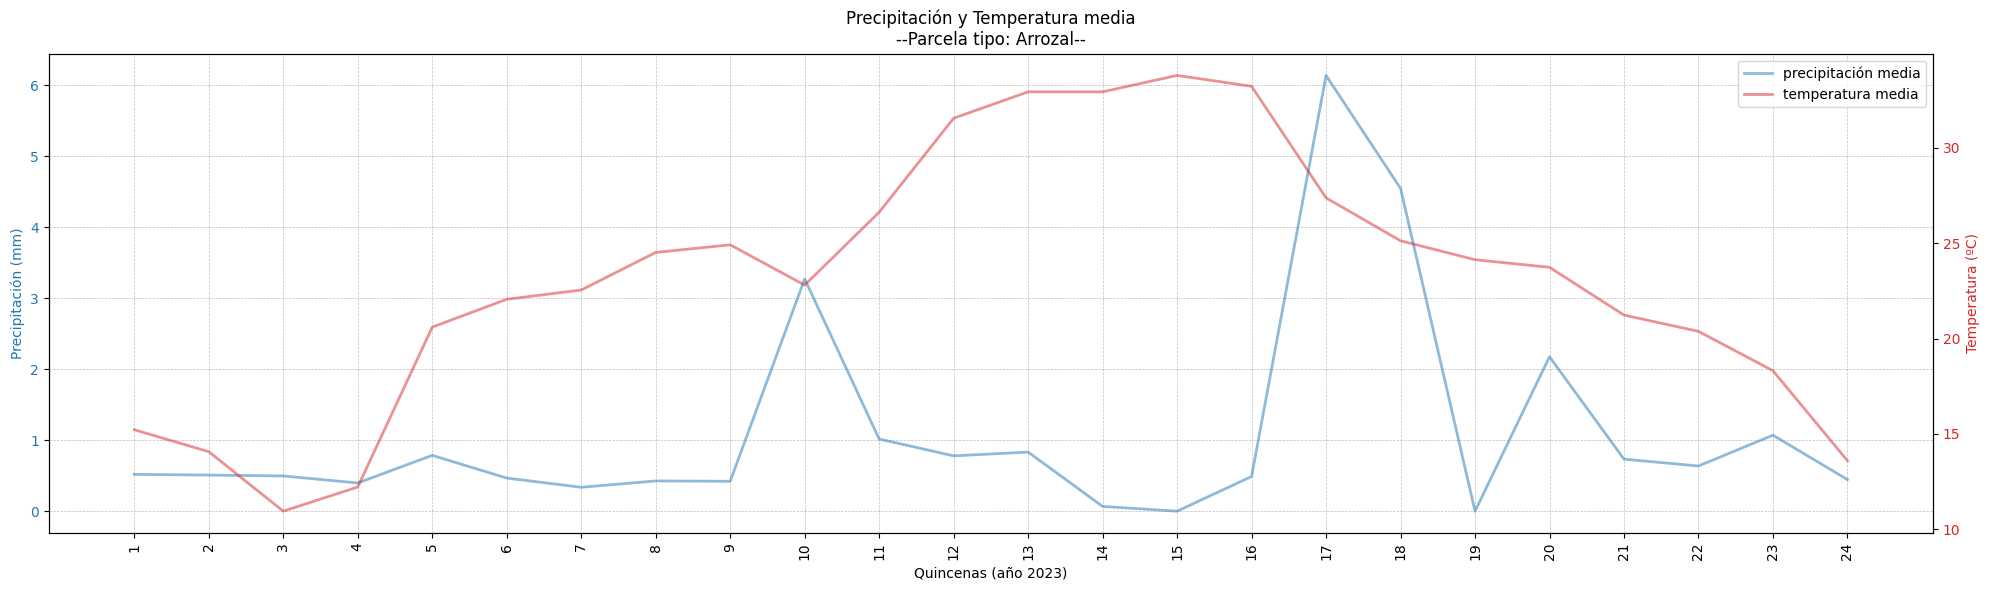

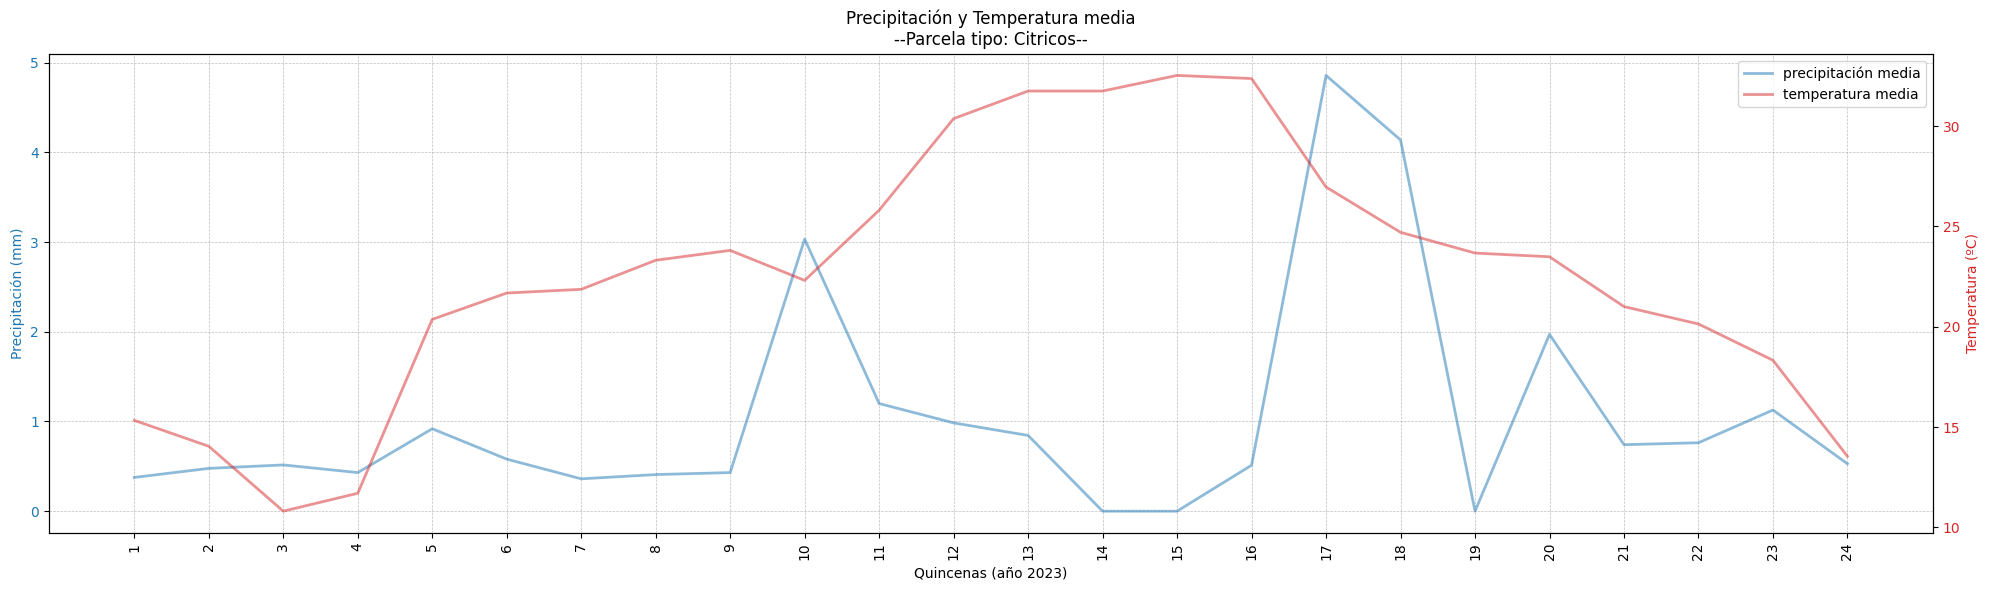

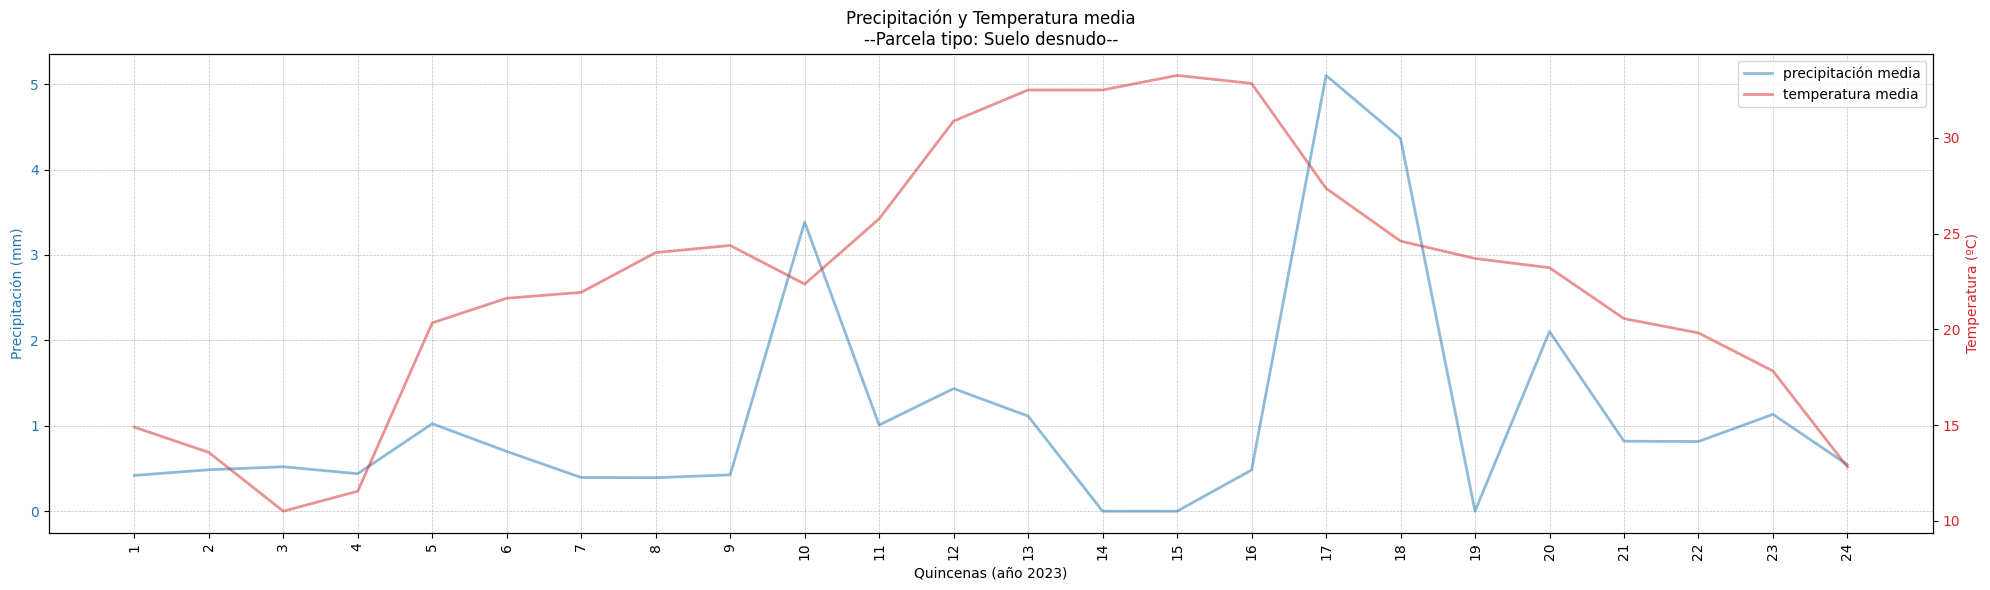

In [ ]:
#graphs
for i in range(data.shape[0]):

    df_precipitacion = data.iloc[i][colNamePrecipitacion]
    df_temperatura = data.iloc[i][colNameTemperatura]

    clase = clases[df_temperatura.EVSAMPLE]
    temperatura = df_temperatura[colNameTemperatura[1:]].values
    precipitacion = df_precipitacion[colNamePrecipitacion[1:]].values

    graficos(clase, quincenas, precipitacion, temperatura)